# Baseline RAG

## Предварительные требования

1. Запустите Qdrant:
    ```
    cd research/rag_experiments
    docker compose up -d
    ```

2. Проиндексируйте документы (один раз):
    ```
    python scripts/index_documents.py --recreate
    ```

In [1]:
import sys

import matplotlib.pyplot as plt
from qdrant_client import QdrantClient

sys.path.insert(0, '..')

from src.config import QDRANT_HOST, QDRANT_PORT, COLLECTION_NAME
from src.generator import Generator
from src.retriever import Retriever

## Информация о проиндексированных данных

In [2]:
client = QdrantClient(host=QDRANT_HOST, port=QDRANT_PORT)
collection_info = client.get_collection(COLLECTION_NAME)

print(f"Collection: {COLLECTION_NAME}")
print(f"Total vectors: {collection_info.points_count}")
print(f"Vector dimension: {collection_info.config.params.vectors.size}")
print(f"Distance metric: {collection_info.config.params.vectors.distance}")

Collection: boardgame_rules
Total vectors: 81898
Vector dimension: 768
Distance metric: Cosine


## Тестирование ретривера

In [3]:
retriever = Retriever()

Using device: mps



🔍 Запрос: Цель игры spyfall


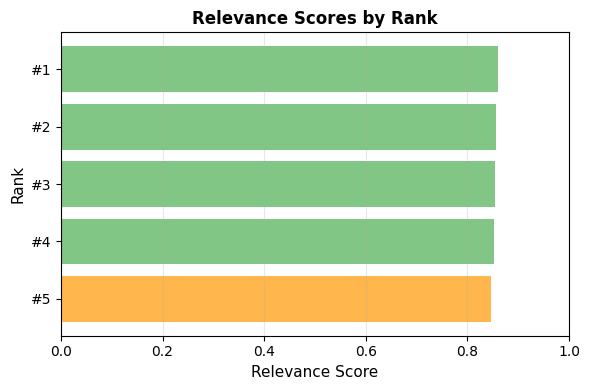


🟢 [1] Spyfall. Звёздные войны
   Score: 0.859 | Lang: ru | Длина: 818 символов
   ────────────────────────────────────────────────────────────────────
   Наблюдатель ность, собранность, выдержка, хитрость — в этой игре пригодится всё. Будьте начеку! Цель игры Цель шпиона повстанцев: не раскрыть себя до окончания раунда или определить локацию, в которой все находятся. Цель остальных игроков: единогласно указать шпиона и, следовательно, разоблачить его. Перед первым раундом Перед первым раундом отсортируйте карты локаций по наборам. В каждом наборе д...

🟢 [2] Spyfall. Звёздные войны
   Score: 0.856 | Lang: ru | Длина: 845 символов
   ────────────────────────────────────────────────────────────────────
   • 180 карт (20 наборов по 9 карт в каждом); • 20 пакетов под карты; • правила игры. Также в процессе игры вам потребуется засекать время, поэтому заблаговременно подготовьте таймер. Наверняка он имеется на мобильном телефоне одного из участников партии.  Обзор игры Игровая партия состо

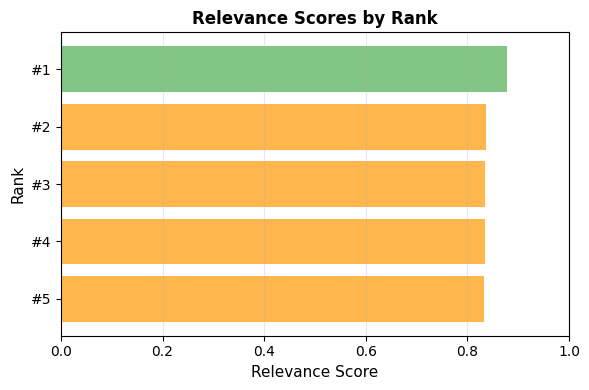


🟢 [1] Крагморта
   Score: 0.878 | Lang: ru | Длина: 365 символов
   ────────────────────────────────────────────────────────────────────
   завершается.  КОНЕЦ ИГРЫ  Игра завершается, когда либо игрок получает четвёртую карту Испепеляющего Взора, либо в колоде Книг Магии не остаётся карт. Побеждает игрок с наименьшим числом карт Испепеляющего Взора. При ничьей побеждает претендент на победу с наибольшим числом Книг Магии. Если и теперь ничья, побеждает тот из  спорщиков, у кого больше символов магии.

🟡 [2] Кроманьонцы
   Score: 0.837 | Lang: ru | Длина: 915 символов
   ────────────────────────────────────────────────────────────────────
   Конец игры и подсчёт победных очков Окончание игры наступает при достижении одним из игроков определённого числа победных очков, которое зависит от количества игроков: 30 очков 24 очка 22 очка Количество игроков Количество ПО 2 игрока 3 игрока 4 игрока Когда один из игроков достигает установленного количества победных очков, он сразу завершает свой

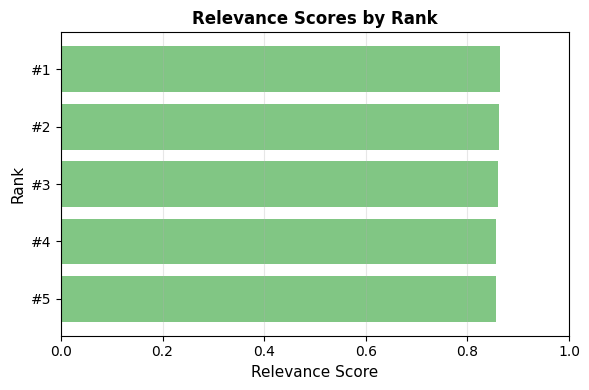


🟢 [1] Бразилия
   Score: 0.865 | Lang: ru | Длина: 751 символов
   ────────────────────────────────────────────────────────────────────
   Всего в игре 24 карты боя. Их можно получить, активируя ячейку действия «Рекрутировать» (даже если у вас не осталось  доступных для рекрутинга военных отрядов) или выставив дворец VI на карту.  За время партии игроки могут разыграть любое число карт боя, но одновременно держать на руке они могут не более трёх таких карт. Если в какой-то моменту игрока на руке оказывается больше трёх карт боя, он н...

🟢 [2] Тор. Рагнарёк
   Score: 0.863 | Lang: ru | Длина: 793 символов
   ────────────────────────────────────────────────────────────────────
   В начале партии, после определения первого игрока выдайте второму и третьему игроку по карте Валькирии, а четвёртому и пятому — по карте Халка. Это их начальные победные очки (положите их вертикально перед собой, оборотной стороной вверх). Первый игрок начальных очков не получает.  Внизу на лицевой стороне кар

In [4]:
test_queries = [
    "Цель игры spyfall",
    "Кто побеждает в конце игры крагморта",
    "Сколько карт раздается в начале игры?",
]


def display_query_results(query, top_k=5):
    results = retriever.retrieve(query, top_k=top_k)
    
    print("\n" + "=" * 70)
    print(f"🔍 Запрос: {query}")
    print("=" * 70)

    if results:
        _, ax1 = plt.subplots(figsize=(6, 4))
        
        scores = [r.score for r in results]
        ranks = list(range(1, len(results) + 1))

        colors = ['#4CAF50' if s > 0.85 else '#FF9800' if s > 0.75 else '#F44336' for s in scores]
        ax1.barh(ranks, scores, color=colors, alpha=0.7)
        ax1.set_xlabel('Relevance Score', fontsize=11)
        ax1.set_ylabel('Rank', fontsize=11)
        ax1.set_title('Relevance Scores by Rank', fontsize=12, fontweight='bold')
        ax1.set_yticks(ranks)
        ax1.set_yticklabels([f"#{r}" for r in ranks])
        ax1.invert_yaxis()
        ax1.grid(axis='x', alpha=0.3)
        ax1.set_xlim(0, 1)
        
        plt.tight_layout()
        plt.show()

    for i, r in enumerate(results, 1):
        games = ", ".join(r.game_titles) if r.game_titles else "Unknown"
        text_preview = r.text[:400].replace("\n", " ").strip()
        if len(r.text) > 400:
            text_preview += "..."

        if r.score > 0.85:
            indicator = "🟢"
        elif r.score > 0.75:
            indicator = "🟡"
        else:
            indicator = "🔴"
        
        print(f"\n{indicator} [{i}] {games}")
        print(f"   Score: {r.score:.3f} | Lang: {r.lang} | Длина: {len(r.text)} символов")
        print(f"   {'─' * 68}")
        print(f"   {text_preview}")
    
    print("\n" + "=" * 70)

    print("\n📊 Сводка:")
    for i, r in enumerate(results, 1):
        games = ", ".join(r.game_titles) if r.game_titles else "Unknown"
        print(f"   {i}. {games[:50]:<50} | {r.score:.3f}")
    
    print()


for query in test_queries:
    display_query_results(query, top_k=5)

### Форматированный контекст для LLM

In [5]:
query = "Цель игры spyfall"
context = retriever.retrieve_with_context(query, top_k=3)

print(f"Запрос: {query}\n")
print("Контекст для LLM:")
print("-" * 70)
print(context)

Запрос: Цель игры spyfall

Контекст для LLM:
----------------------------------------------------------------------
[1] Игра: Spyfall. Звёздные войны
Релевантность: 0.859
---
Наблюдатель ность, собранность, выдержка, хитрость — в этой игре пригодится всё. Будьте начеку! Цель игры Цель шпиона повстанцев: не раскрыть себя до окончания раунда или определить локацию, в которой все находятся. Цель остальных игроков: единогласно указать шпиона и, следовательно, разоблачить его. Перед первым раундом Перед первым раундом отсортируйте карты локаций по наборам. В каждом наборе долж но быть 8 карт с одинаковыми иллюстра циями и 1 карта шпиона. Положите каждый набор карт в отдельный пакет: все карты на бора должны лежать лицевой стороной вниз, причём так, чтобы внизу была карта шпиона. На следующих страницах изображены все локации. Перед началом раунда игроки должны внимательно изучить этот разворот. Это поможет будущим «шпионам» понять, из каких локаций им предстоит выбирать во время игры.


[2] 

### Анализ результатов тестирования ретривера

#### Положительные результаты

**Высокая точность на конкретных запросах**
   - Запрос "Цель игры spyfall": все 5 результатов про Spyfall (последний про Spycon, но они похожи), scores 0.846-0.859
   - Система корректно находит релевантные документы для специфичных запросов

**Хорошая работа с тематическими запросами**
   - Запрос "Кто побеждает в конце игры крагморта": первый результат - Крагморта (0.878), что является очень высоким score
   - Топ-3 результата про Крагморту (scores 0.878, 0.834, 0.834), что показывает хорошую способность находить нужную игру
   - Система находит нужную игру и возвращает семантически похожие результаты

**Стабильно высокие scores**
   - Большинство scores > 0.85, что указывает на хорошее качество эмбеддингов
   - Для конкретных запросов с указанием игры scores достигают 0.87-0.88

### Проблемы и ограничения

**Общие запросы дают разнородные результаты**
   - Запрос "Сколько карт раздается в начале игры?": результаты из разных игр (Бразилия, Тор, Тортуга и др.), но это ожидаемо для общего вопроса без указания конкретной игры
   - Scores для общего запроса также высокие (0.855-0.865), что показывает хорошее качество эмбеддингов даже для общих вопросов

## Генерация ответов с помощью LLM

Теперь добавим LLM для генерации ответов на основе найденного контекста.

In [ ]:
generator = Generator()
print(f"LLM Provider: {generator.llm.__class__.__name__}")
print(f"LLM Model: {generator.llm.model if hasattr(generator.llm, 'model') else 'N/A'}")

Using device: mps
LLM Provider: Ollama
LLM Model: qwen2.5:1.5b


### Примеры генерации ответов

In [8]:
test_queries = [
    "Цель игры spyfall",
    "Кто побеждает в конце игры крагморта",
    "Сколько карт раздается в начале игры Таверна Красный Дракон?",
]

for query in test_queries:
    print("=" * 70)
    print(f"🔍 Вопрос: {query}")
    print("=" * 70)

    context = retriever.retrieve_with_context(query, top_k=3)
    print("\n📚 Использованный контекст:")
    print("-" * 70)
    print(context[:500] + "..." if len(context) > 500 else context)

    print("\n💬 Ответ:")
    print("-" * 70)
    try:
        answer = generator.generate(query, top_k=3)
        print(answer)
    except Exception as e:
        print(f"❌ Ошибка генерации: {e}")
        print("\n💡 Убедитесь, что:")
        print("   - Для Ollama: сервис запущен (ollama serve) и модель загружена")
        print("   - Для OpenAI: установлена переменная окружения OPENAI_API_KEY")
    
    print("\n")

🔍 Вопрос: Цель игры spyfall

📚 Использованный контекст:
----------------------------------------------------------------------
[1] Игра: Spyfall. Звёздные войны
Релевантность: 0.859
---
Наблюдатель ность, собранность, выдержка, хитрость — в этой игре пригодится всё. Будьте начеку! Цель игры Цель шпиона повстанцев: не раскрыть себя до окончания раунда или определить локацию, в которой все находятся. Цель остальных игроков: единогласно указать шпиона и, следовательно, разоблачить его. Перед первым раундом Перед первым раундом отсортируйте карты локаций по наборам. В каждом наборе долж но быть 8 карт с одинаковыми иллюстра...

💬 Ответ:
----------------------------------------------------------------------
Цель игры Spyfall — разыскать планы "Звезды Смерти" и не раскрыть себя до окончания раунда или определить локацию, в которой все находятся.


🔍 Вопрос: Кто побеждает в конце игры крагморта

📚 Использованный контекст:
----------------------------------------------------------------------


### Сравнение: RAG vs LLM без контекста

Чтобы понять, помогает ли RAG, запустим те же запросы **без** контекста из базы - только LLM по вопросу. Если без контекста модель не знает ответ или выдумывает, а с RAG отвечает по правилам - RAG действительно полезен.

In [9]:
for query in test_queries:
    print("=" * 70)
    print(f"🔍 Вопрос: {query}")
    print("=" * 70)
    
    print("\n📌 С RAG (контекст из базы):")
    print("-" * 70)
    try:
        answer_rag = generator.generate(query, top_k=3)
        print(answer_rag)
    except Exception as e:
        print(f"❌ Ошибка: {e}")
    
    print("\n📌 Без RAG (только LLM, без контекста):")
    print("-" * 70)
    try:
        answer_no_rag = generator.generate_without_context(query)
        print(answer_no_rag)
    except Exception as e:
        print(f"❌ Ошибка: {e}")
    
    print("\n")

🔍 Вопрос: Цель игры spyfall

📌 С RAG (контекст из базы):
----------------------------------------------------------------------
Цель игры Spyfall — разыскать планы "Звезды Смерти" и не раскрыть себя до окончания раунда или определить локацию, в которой все находятся.

📌 Без RAG (только LLM, без контекста):
----------------------------------------------------------------------
Цель игры "Spyfall" заключается в выживании и уничтожении конкурентов, используя свои навыки и информацию.


🔍 Вопрос: Кто побеждает в конце игры крагморта

📌 С RAG (контекст из базы):
----------------------------------------------------------------------
Бывает, что игрок с наименьшим числом карт Испепеляющего Взора выигрывает. Если и тогда ничья, побеждает тот из спорщиков, у кого больше символов магии.

📌 Без RAG (только LLM, без контекста):
----------------------------------------------------------------------
В конце игры крагморта победит "Джон" из команды "Супер Стэйдж".


🔍 Вопрос: Сколько карт раздается в

### Анализ результатов работы RAG-пайплайна

#### Положительные результаты

**RAG действительно помогает**
   - С RAG: модель отвечает на основе найденных правил из базы
   - Без RAG: модель часто не знает конкретику или выдумывает ответы (например, "Джон" из команды "Супер Стэйдж" для крагморты, "4 карта" вместо "40 карт")
   - Это подтверждает ценность RAG для доменно-специфичных вопросов

**Качество ответов с RAG**
   - Ответы основаны на реальных правилах из базы данных
   - Для простых фактологических вопросов ("Сколько карт раздается?") модель дает точные краткие ответы ("40 карт")
   - Формулировки краткие и по делу (благодаря низкой температуре 0.1)

**Работа с конкретными запросами**
   - Запросы с указанием игры ("Цель игры spyfall") дают релевантные ответы на основе контекста
   - Система успешно извлекает информацию из релевантных чанков

#### Проблемы и ограничения

**Неполнота ответов для сложных вопросов**
   - Для вопроса "Кто побеждает в конце игры крагморта" модель дает неполный ответ: "Бывает, что и здесь тоже приходится решать. Если и теперь ничья, побеждает тот из спорщиков, у кого больше символов магии."
   - Хотя в контексте четко указано: "Побеждает игрок с наименьшим числом карт Испепеляющего Взора", модель пропускает основное условие победы
   - Это может быть связано с тем, что модель фокусируется на конце предложения (условия ничьей) вместо начала (основное правило)

**Ограничения модели**
   - Небольшая модель (qwen2.5:1.5b) может иметь ограничения в понимании структурированных правил
   - Модель иногда не извлекает полную информацию из контекста, даже когда она явно присутствует
   - Возможно, требуется более явное структурирование контекста или использование только топ-1 результата для очень конкретных вопросов

**Зависимость от качества ретривера**
   - Ретривер работает отлично (score 0.878 для крагморты), но генератор не всегда использует всю релевантную информацию
   - Нет механизма приоритизации основной информации над второстепенной

**Общие запросы**
   - Запросы без указания конкретной игры могут давать ответы из разных игр
   - Модель пытается объединить информацию, что может быть некорректно

#### Варианты для улучшения

**Дальнейшее улучшение промптов**
   - Добавить явное указание начинать с основного правила, а затем упоминать исключения
   - Структурировать ответ (например, "Согласно правилам игры X...")
   - Добавить обработку случаев отсутствия информации

**Фильтрация и приоритизация контекста**
   - Для очень конкретных вопросов использовать только топ-1 результат (где основная информация)
   - Добавить порог релевантности (не использовать чанки с score < 0.7)
   - Фильтровать дублирующуюся информацию
   - Приоритизировать чанки из одной игры для конкретных запросов

**Обработка структурированных правил**
   - Если контекст содержит структурированные правила (основное правило + исключения), явно указать модели начинать с основного
   - Использовать более структурированный формат контекста (например, выделять основные правила)

**Использование более мощных моделей**
   - Для более сложных вопросов может потребоваться более мощная модель
   - Текущая модель (qwen2.5:1.5b) хорошо работает для простых фактологических вопросов, но может иметь ограничения для сложных

**Общий вывод:** RAG пайплайн работает и значительно улучшает качество ответов по сравнению с vanilla LLM. После улучшения промптов ответы стали более точными для простых вопросов, но для сложных вопросов со структурированными правилами все еще остаются проблемы с полнотой ответов. Основные направления для улучшения: приоритизация основной информации в контексте, использование только топ-1 результата для конкретных вопросов, и возможное использование более мощных моделей для сложных случаев.